In [1]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/imdb-sentiment-classification'
    import subprocess
    subprocess.run(['pip', 'install', 'mlflow', '-q'])
else:
    try:
        torch_lib = os.path.join(
            os.environ.get('VIRTUAL_ENV', ''),
            'Lib', 'site-packages', 'torch', 'lib'
        )
        if os.path.exists(torch_lib):
            os.add_dll_directory(torch_lib)
    except Exception:
        pass
    BASE_PATH = os.path.abspath('..')

RESULTS_PATH = f'{BASE_PATH}/results'
sys.path.insert(0, BASE_PATH)

import torch
print(f'Torch:  {torch.__version__}')
print(f'Colab:  {IN_COLAB}')
print(f'GPU:    {torch.cuda.is_available()}')
print(f'Base:   {BASE_PATH}')

Torch:  2.12.0+cpu
Colab:  False
GPU:    False
Base:   c:\Users\Iva\Desktop\imdb-sentiment-classification


In [2]:
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

from models.autoencoder import TfidfAutoencoder
from models.svm import SVMModel
from evaluation.metrics import ClassificationMetrics

c:\Users\Iva\AppData\Local\pypoetry\Cache\virtualenvs\imdb-sentiment-classification-S-I29JL4-py3.11\Lib\site-packages\pydantic\_internal\_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


In [3]:
if IN_COLAB:
    data_path = '/content'
else:
    data_path = RESULTS_PATH

with open(f'{data_path}/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

df_train = splits['train']
df_val   = splits['val']
df_test  = splits['test']

with open(f'{data_path}/shared_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

X_train = vectorizer.transform(df_train)
X_val   = vectorizer.transform(df_val)
X_test  = vectorizer.transform(df_test)

y_train = df_train['sentiment'].values
y_val   = df_val['sentiment'].values
y_test  = df_test['sentiment'].values

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (40000, 139992)
X_val:   (5000, 139992)
X_test:  (5000, 139992)


In [4]:
if IN_COLAB:
    mlflow.set_tracking_uri(f'file://{BASE_PATH}/mlruns')
else:
    mlflow.set_tracking_uri(f'file:///{BASE_PATH}/mlruns'.replace('\\', '/'))

mlflow.set_experiment('imdb-sentiment')

<Experiment: artifact_location='file:///c:/Users/Iva/Desktop/imdb-sentiment-classification/mlruns/397932824360539574', creation_time=1779195973368, experiment_id='397932824360539574', last_update_time=1779195973368, lifecycle_stage='active', name='imdb-sentiment', tags={}>

In [ ]:
RETRAIN = True

input_dim  = X_train.shape[1]
hidden_dim = 1024
latent_dim = 256
n_epochs   = 20
batch_size = 64
lr         = 1e-3

autoencoder = TfidfAutoencoder(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    n_epochs=n_epochs,
    batch_size=batch_size,
    learning_rate=lr,
    classification_weight=1.0,
)

if IN_COLAB:
    ENCODER_PATH = '/content/drive/MyDrive/encoder.pt'
else:
    ENCODER_PATH = f'{RESULTS_PATH}/encoder.pt'

if RETRAIN:
    with mlflow.start_run(run_name='autoencoder_training_semisupervised', tags={'study': 'autoencoder'}):
        mlflow.log_params(autoencoder.get_params())
        history = autoencoder.train(X_train, X_val, y_train, y_val)
        for epoch, (tl, vl) in enumerate(zip(history['train_loss'], history['val_loss'])):
            mlflow.log_metrics({'train_loss': tl, 'val_loss': vl}, step=epoch)
        mlflow.log_metric('training_time_s', autoencoder.training_time)

    torch.save({
        'encoder':    autoencoder._encoder.state_dict(),
        'classifier': autoencoder._classifier.state_dict(),
    }, ENCODER_PATH)
    print(f'Encoder saved to {ENCODER_PATH}. Training time: {autoencoder.training_time:.1f}s')
else:
    checkpoint = torch.load(ENCODER_PATH, map_location=autoencoder.device)
    autoencoder._encoder.load_state_dict(checkpoint['encoder'])
    autoencoder._classifier.load_state_dict(checkpoint['classifier'])
    autoencoder._is_trained = True
    print(f'Encoder loaded from {ENCODER_PATH}')

Encoder loaded from c:\Users\Iva\Desktop\imdb-sentiment-classification/results/encoder.pt


In [6]:
if RETRAIN:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history['train_loss'], label='Train loss')
    ax.plot(history['val_loss'],   label='Val loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Autoencoder Reconstruction Loss')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Loss curve not available — encoder loaded, not trained.')

Loss curve not available — encoder loaded, not trained.


In [7]:
X_train_latent = autoencoder.encode(X_train)
X_val_latent   = autoencoder.encode(X_val)
X_test_latent  = autoencoder.encode(X_test)

print(f'Latent train: {X_train_latent.shape}')
print(f'Latent val:   {X_val_latent.shape}')
print(f'Latent test:  {X_test_latent.shape}')
print(f'Compression:  {input_dim} → {latent_dim} ({input_dim // latent_dim}x)')

Latent train: (40000, 256)
Latent val:   (5000, 256)
Latent test:  (5000, 256)
Compression:  139992 → 256 (546x)


In [8]:
svm_latent = SVMModel()

t0 = time.perf_counter()
svm_latent.train(X_train_latent, y_train)
train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_test = svm_latent.predict(X_test_latent)
inf_time = time.perf_counter() - t0

latent_metrics = ClassificationMetrics(
    y_true=y_test,
    y_pred=y_pred_test,
    training_time=train_time,
    inference_time=inf_time,
    n_features=X_test_latent.shape[1],
)

with mlflow.start_run(run_name='svm_on_latent', tags={'study': 'autoencoder'}):
    mlflow.log_params({
        'model':      'SVMModel',
        'features':   'autoencoder_latent',
        'latent_dim': latent_dim,
    })
    mlflow.log_metrics({f'test_{k}': v for k, v in latent_metrics.to_dict().items()})

print(latent_metrics.report())

2026/05/25 09:10:44 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



              precision    recall  f1-score   support

    negative       0.86      0.90      0.88      2500
    positive       0.89      0.85      0.87      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [9]:
RAW_TFIDF_F1       = 0.9073  # from notebook 03 — SVM best config
RAW_TFIDF_ACCURACY = 0.9072

comparison = pd.DataFrame([
    {
        'features':        'Raw TF-IDF',
        'n_features':      input_dim,
        'test_f1':         RAW_TFIDF_F1,
        'test_accuracy':   RAW_TFIDF_ACCURACY,
    },
    {
        'features':        f'Autoencoder latent (dim={latent_dim})',
        'n_features':      latent_dim,
        'test_f1':         round(latent_metrics.f1, 4),
        'test_accuracy':   round(latent_metrics.accuracy, 4),
    },
])
comparison['compression_ratio'] = (input_dim / comparison['n_features']).round(0).astype(int).astype(str) + 'x'
comparison

,features,n_features,test_f1,test_accuracy,compression_ratio
0,Raw TF-IDF,139992,0.9073,0.9072,1x
1,Autoencoder latent (dim=256),256,0.8737,0.8766,547x


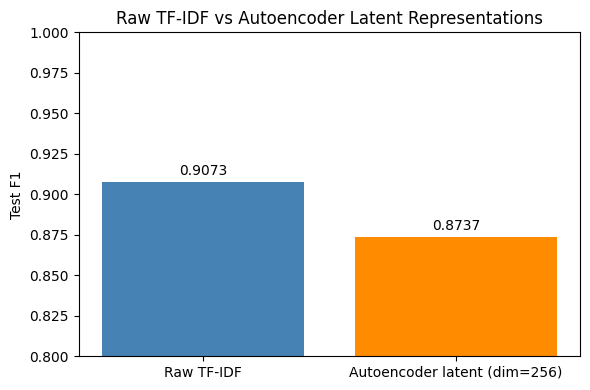

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(comparison['features'], comparison['test_f1'],
              color=['steelblue', 'darkorange'])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Test F1')
ax.set_title('Raw TF-IDF vs Autoencoder Latent Representations')
plt.tight_layout()
plt.show()

In [13]:
N_SAMPLE = 1000
np.random.seed(42)
idx = np.random.choice(len(X_test_latent), N_SAMPLE, replace=False)

X_sample = X_test_latent[idx]
y_sample = y_test[idx]


X_pos = X_sample[y_sample == 'positive']
X_neg = X_sample[y_sample == 'negative']

sim_pos = cosine_similarity(X_pos)
sim_neg = cosine_similarity(X_neg)
np.fill_diagonal(sim_pos, np.nan)
np.fill_diagonal(sim_neg, np.nan)

intra_pos = np.nanmean(sim_pos)
intra_neg = np.nanmean(sim_neg)
inter     = np.mean(cosine_similarity(X_pos, X_neg))

print(f'Intra-class similarity (positive): {intra_pos:.4f}')
print(f'Intra-class similarity (negative): {intra_neg:.4f}')
print(f'Inter-class similarity:            {inter:.4f}')
print(f'\nIntra > Inter: {(intra_pos + intra_neg) / 2 > inter}')

Intra-class similarity (positive): 0.5273
Intra-class similarity (negative): 0.6001
Inter-class similarity:            0.5479

Intra > Inter: True


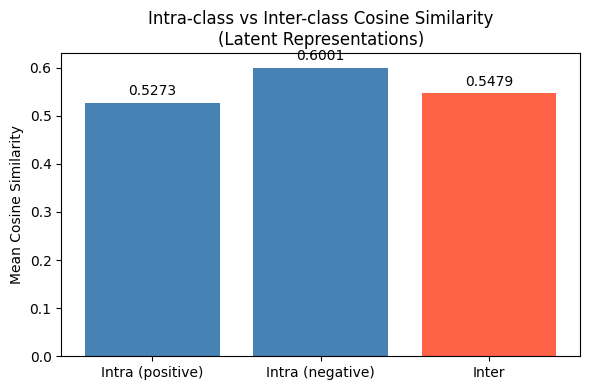

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Intra (positive)', 'Intra (negative)', 'Inter'],
    [intra_pos, intra_neg, inter],
    color=['steelblue', 'steelblue', 'tomato']
)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylabel('Mean Cosine Similarity')
ax.set_title('Intra-class vs Inter-class Cosine Similarity\n(Latent Representations)')
plt.tight_layout()
plt.show()

Running t-SNE (this may take a minute)...


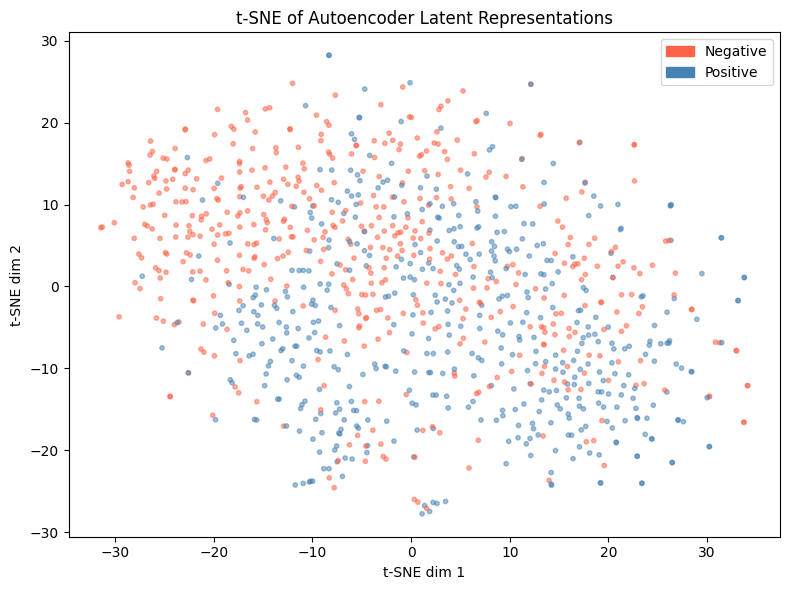

In [18]:
print('Running t-SNE (this may take a minute)...')

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if y == 'negative' else 'steelblue' for y in y_sample]
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.5, s=10)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='tomato',    label='Negative'),
    Patch(color='steelblue', label='Positive'),
])
ax.set_title('t-SNE of Autoencoder Latent Representations')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

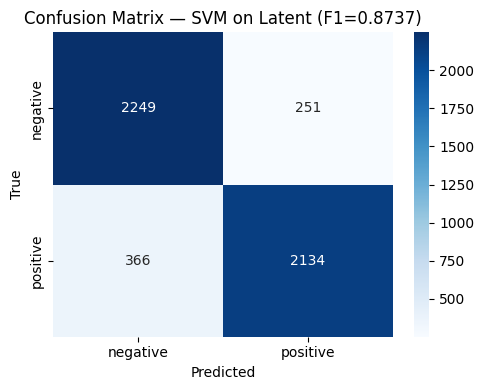

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    latent_metrics.confusion_matrix,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive'],
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — SVM on Latent (F1={latent_metrics.f1:.4f})')
plt.tight_layout()
plt.show()